# Classificação da Faixa de Renda de Adultos

**Etapa 1: Análise Exploratória de Dados (EDA) e pré-processamento**

**Aluno:** Leonardo Moretti Alva

**Dataset:** [Adult Income Census (Kaggle)](https://www.kaggle.com/datasets/anaghakp/adult-income-census), versão do dataset *Adult* do UCI Machine Learning Repository, extraído do Censo dos EUA de 1994.

**Objetivo:** prever se a renda anual de uma pessoa é maior que 50 mil dólares (`>50K`) ou não (`<=50K`). É um problema de **classificação binária**.

## 1. Carregamento e inspeção inicial dos dados

### 1.1 Descrição das features

| Variável | Descrição | Tipo |
|---|---|---|
| `age` | Idade em anos | Numérica |
| `workclass` | Tipo de vínculo de trabalho (privado, governo, autônomo...) | Categórica |
| `fnlwgt` | *Final weight*: peso amostral do Censo, isto é, quantas pessoas da população o registro representa. Não descreve a pessoa | Numérica |
| `education` | Nível educacional em texto | Categórica |
| `education_num` | O mesmo nível educacional em número (1 = pré-escola ... 16 = doutorado) | Numérica |
| `marital_status` | Estado civil | Categórica |
| `occupation` | Ocupação | Categórica |
| `relationship` | Papel na família (marido, esposa, filho...) | Categórica |
| `race` | Raça | Categórica |
| `sex` | Sexo | Categórica |
| `native_country` | País de origem | Categórica |
| `income` | Faixa de renda: `<=50K` ou `>50K` | **Alvo** |

Observações iniciais:

- Esta versão do Kaggle tem 11 features. O dataset original da UCI tem também `capital_gain`, `capital_loss` e `hours_per_week`, que não estão neste arquivo.
- `education` e `education_num` parecem carregar a mesma informação, e `fnlwgt` é um artefato da amostragem do Censo. As duas questões são verificadas na EDA e tratadas no pré-processamento.

In [1]:
# Manipulação de dados e gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Divisão treino/teste, pipeline de pré-processamento e PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42  # semente fixa para os resultados serem reproduzíveis

### 1.2 Carregamento

O arquivo `adult income1.csv`, baixado do Kaggle, deve estar na mesma pasta do notebook. O dataset marca valores ausentes com `?`, que são convertidos para `NaN` na leitura.

In [2]:
# Lê o CSV do Kaggle, tratando '?' como valor ausente.
data = pd.read_csv('adult income1.csv', na_values='?')

# Padroniza os nomes das colunas: 'education.num' vira 'education_num'.
data.columns = data.columns.str.replace('.', '_', regex=False)

print(f'Instâncias: {data.shape[0]:,} | Features: {data.shape[1] - 1}')
data.head()

Instâncias: 31,947 | Features: 11


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,native_country,income
0,17,Private,148522,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
1,17,Private,93235,12th,8,Never-married,occupation,Own-child,White,Female,United-States,<=50K
2,17,Private,184924,9th,5,Never-married,occupation,Own-child,White,Male,United-States,<=50K
3,17,Private,116626,11th,7,Never-married,occupation,Own-child,White,Male,United-States,<=50K
4,17,Private,209949,11th,7,Never-married,occupation,Own-child,White,Female,United-States,<=50K


### 1.3 Inconsistências

Já nas primeiras linhas aparece um problema: a coluna `occupation` contém o texto "occupation", o nome da própria coluna, no lugar de uma ocupação. A célula abaixo mede esse problema e também verifica as faixas das numéricas e a coerência entre `education` e `education_num`.

In [3]:
# 1) Valor inválido: o nome da coluna aparece como valor em occupation.
invalido = data['occupation'] == 'occupation'
print("Linhas com occupation = 'occupation':", invalido.sum())

# Compara a % de renda alta desse grupo com a dos ausentes ('?') e a do restante.
def taxa_renda_alta(linhas):
    return round((data.loc[linhas, 'income'] == '>50K').mean() * 100, 1)

print('% de >50K | valor inválido:', taxa_renda_alta(invalido),
      '| ausente (?):', taxa_renda_alta(data['occupation'].isna()),
      '| ocupação válida:', taxa_renda_alta(~invalido & data['occupation'].notna()))

# Mantém o grupo como uma categoria própria, sem misturá-lo com os ausentes.
data['occupation'] = data['occupation'].replace('occupation', 'Inválido')

# 2) Faixas das numéricas, para detectar valores impossíveis.
display(data[['age', 'fnlwgt', 'education_num']].agg(['min', 'max']))

# 3) Coerência: cada nível de education deve ter um único código em education_num.
print('Cada education corresponde a um único education_num:',
      data.groupby('education')['education_num'].nunique().max() == 1)

Linhas com occupation = 'occupation': 1462
% de >50K | valor inválido: 52.8 | ausente (?): 9.8 | ocupação válida: 23.5


,age,fnlwgt,education_num
min,17,12285,1
max,90,1484705,16


Cada education corresponde a um único education_num: True


**Interpretação**

- **Valor inválido em `occupation`:** 1.462 linhas, cerca de 4,6% da base, têm "occupation" no lugar da ocupação. É um erro do arquivo, mas não é aleatório: cerca de 53% dessas pessoas ganham `>50K`, contra cerca de 10% das que têm `?` e 23,5% das demais. Por isso o grupo vira a categoria `Inválido` em vez de ser tratado como ausente. Juntar os dois grupos misturaria perfis de renda opostos.
- **Faixas numéricas:** idade de 17 a 90 anos e escolaridade de 1 a 16. Não há valores impossíveis.
- **`education` × `education_num`:** cada nível de escolaridade tem exatamente um código. As duas colunas são a mesma informação, o que justifica descartar uma delas.

### 1.4 Tipos de dados, valores ausentes e duplicatas

In [4]:
# Resumo por coluna: tipo, ausentes (quantidade e %) e número de valores distintos.
quality = pd.DataFrame({
    'tipo': data.dtypes,
    'ausentes': data.isna().sum(),
    'ausentes_%': (data.isna().mean() * 100).round(2),
    'valores_unicos': data.nunique()
})
display(quality)

# Verifica se workclass e occupation faltam nas mesmas linhas.
print('Linhas sem workclass:', data['workclass'].isna().sum())
print('Dessas, também sem occupation:', (data['workclass'].isna() & data['occupation'].isna()).sum())

# Remove linhas completamente duplicadas.
print('Duplicatas completas:', data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
print(f'Instâncias após remover duplicatas: {len(data):,}')

,tipo,ausentes,ausentes_%,valores_unicos
age,int64,0,0.00,73
workclass,object,1778,5.57,8
fnlwgt,int64,0,0.00,21381
education,object,0,0.00,16
education_num,int64,0,0.00,16
marital_status,object,0,0.00,7
occupation,object,1785,5.59,15
relationship,object,0,0.00,6
race,object,0,0.00,5
sex,object,0,0.00,2


Linhas sem workclass: 1778
Dessas, também sem occupation: 1778
Duplicatas completas: 65
Instâncias após remover duplicatas: 31,882


**Interpretação**

- São 3 variáveis numéricas (inteiras) e 8 categóricas, além do alvo.
- Só três colunas têm ausentes: `workclass` e `occupation`, com cerca de 5,6% cada, e `native_country`, com menos de 0,1%.
- Todas as linhas sem `workclass` também estão sem `occupation`. O `?` marca pessoas sem vínculo de trabalho declarado, e só cerca de 10% delas ganham `>50K` (seção 1.3). A ausência carrega informação, o que orienta a imputação na seção 4.
- As 65 duplicatas, cerca de 0,2% da base, foram removidas para que a mesma linha não caia no treino e no teste ao mesmo tempo, o que inflaria as métricas.

### 1.5 Desbalanceamento de classes

,frequencia,percentual
income,,
<=50K,24209,75.93
>50K,7673,24.07


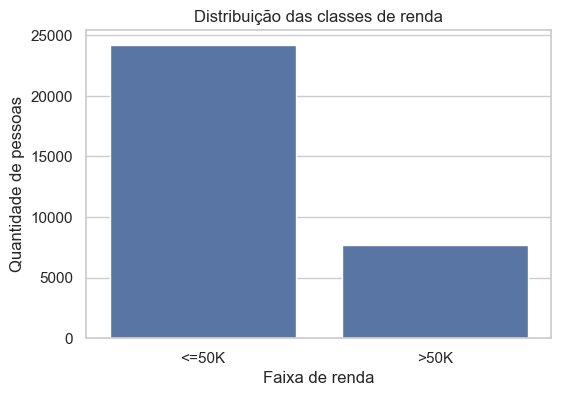

In [5]:
# Frequência e percentual de cada classe do alvo.
counts = data['income'].value_counts()
display(pd.DataFrame({'frequencia': counts, 'percentual': (counts / len(data) * 100).round(2)}))

# Gráfico de barras com a contagem de cada classe.
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='income', order=counts.index)
plt.title('Distribuição das classes de renda')
plt.xlabel('Faixa de renda')
plt.ylabel('Quantidade de pessoas')
plt.show()

**Interpretação:** as classes estão desbalanceadas na proporção de cerca de **3:1**, com 76% `<=50K` e 24% `>50K`. Consequências para a modelagem:

1. A acurácia engana: um modelo que sempre prevê `<=50K` já acerta 76%. As métricas devem ser precisão, recall, F1-score e ROC-AUC.
2. A separação treino/teste deve ser estratificada, e vale testar `class_weight='balanced'` nos modelos.

### 1.6 Separação treino/teste

A divisão é feita antes de qualquer transformação ajustada aos dados. As seções 2 e 3 descrevem a base completa, mas imputação, codificação e escala do pipeline (seção 4) são aprendidas só no treino, o que evita vazamento de dados. As limpezas das seções 1.3 e 1.4 vêm antes porque seguem regras fixas e não aprendem nada dos dados. O `stratify` mantém a proporção 3:1 nos dois conjuntos.

In [6]:
# Separa as features (X) do alvo (y).
X = data.drop(columns='income')
y = data['income']

# 80% treino e 20% teste, mantendo a proporção das classes.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('% de >50K no treino:', round((y_train == '>50K').mean() * 100, 2))
print('% de >50K no teste: ', round((y_test == '>50K').mean() * 100, 2))

Treino: (25505, 11) | Teste: (6377, 11)
% de >50K no treino: 24.07
% de >50K no teste:  24.07


## 2. Análise univariada

### 2.1 Variáveis numéricas

O dataset tem exatamente três variáveis numéricas, `age`, `fnlwgt` e `education_num`, então as estatísticas e os gráficos cobrem todas elas dentro do limite de três. Os histogramas mostram a forma de cada distribuição, e os boxplots destacam os outliers que orientam a estratégia da seção 4.

,mean,mediana,std,min,max,assimetria
age,38.59,37.0,13.64,17.0,90.0,0.56
fnlwgt,189749.21,178253.0,105796.06,12285.0,1484705.0,1.45
education_num,10.07,10.0,2.56,1.0,16.0,-0.31


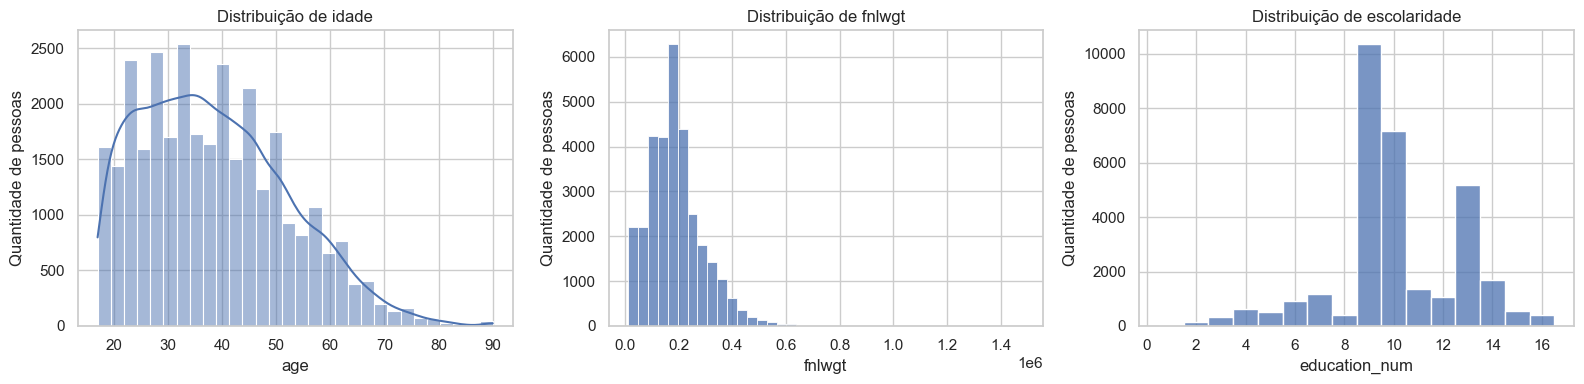

In [7]:
numeric_cols = ['age', 'fnlwgt', 'education_num']

# Estatísticas descritivas: média, mediana, desvio padrão, extremos e assimetria.
stats = data[numeric_cols].describe().T[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'mediana'})
stats['assimetria'] = data[numeric_cols].skew()
display(stats.round(2))

# Histogramas. education_num é discreta, então cada nível ganha uma barra própria.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=data, x='age', bins=30, kde=True, ax=axes[0]).set_title('Distribuição de idade')
sns.histplot(data=data, x='fnlwgt', bins=40, ax=axes[1]).set_title('Distribuição de fnlwgt')
sns.histplot(data=data, x='education_num', discrete=True, ax=axes[2]).set_title('Distribuição de escolaridade')
for ax in axes:
    ax.set_ylabel('Quantidade de pessoas')
plt.tight_layout()
plt.show()

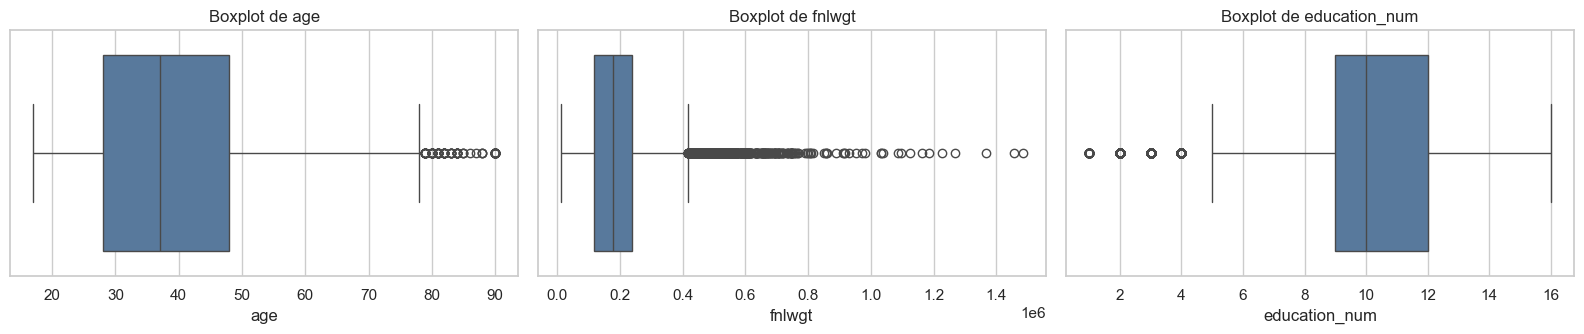

age: 0 abaixo de -2.0 | 139 acima de 78.0
fnlwgt: 0 abaixo de -62,188.9 | 959 acima de 417,302.1
education_num: 1155 abaixo de 4.5 | 0 acima de 16.5


In [8]:
# Boxplots das três numéricas.
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=data, x=col, ax=ax, color='#4c78a8')
    ax.set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

# Conta os outliers pela mesma regra do boxplot: além de 1,5 intervalo interquartil dos quartis.
for col in numeric_cols:
    q1, q3 = data[col].quantile([0.25, 0.75])
    limite_inf, limite_sup = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    print(f'{col}: {(data[col] < limite_inf).sum()} abaixo de {limite_inf:,.1f} | '
          f'{(data[col] > limite_sup).sum()} acima de {limite_sup:,.1f}')

**Interpretação**

- `age`: assimetria positiva leve, média de 38,6 e mediana de 37 anos. O boxplot marca 139 pessoas acima de 78 anos como outliers, mas são idades plausíveis.
- `fnlwgt`: a variável mais assimétrica, com 959 outliers acima de cerca de 417 mil. Como é um peso amostral, essa assimetria não diz nada sobre as pessoas.
- `education_num`: concentrada nos níveis 9 (*HS-grad*), 10 (*Some-college*) e 13 (*Bachelors*). Os 1.155 outliers abaixo de 4,5 são apenas os níveis de escolaridade mais baixos, categorias válidas e raras.

### 2.2 Variáveis categóricas

A tabela resumo cobre todas as categóricas: número de categorias, categoria mais comum e seu percentual na base. Para as frequências detalhadas e os gráficos foram escolhidas `education`, `occupation` e `marital_status`, porque têm várias categorias com frequências espalhadas, que o gráfico mostra melhor que a tabela. `native_country` tem mais categorias, mas mais de 90% dos registros são de um só país, e o gráfico seria praticamente uma barra.

,unique,top,freq,freq_%
workclass,8,Private,22230,69.7
education,16,HS-grad,10341,32.4
marital_status,7,Married-civ-spouse,14654,46.0
occupation,15,Craft-repair,3831,12.0
relationship,6,Husband,12912,40.5
race,5,White,27345,85.8
sex,2,Male,21316,66.9
native_country,41,United-States,29062,91.2


,%
education,
HS-grad,32.4
Some-college,22.4
Bachelors,16.3
Masters,5.2
Assoc-voc,4.3
11th,3.6
Assoc-acdm,3.3
10th,2.9
7th-8th,2.0


,%
occupation,
Craft-repair,12.0
Prof-specialty,11.7
Exec-managerial,11.6
Adm-clerical,11.3
Sales,10.6
Other-service,9.8
Machine-op-inspct,6.0
Ausente,5.6
Transport-moving,4.7


,%
marital_status,
Married-civ-spouse,46.0
Never-married,32.7
Divorced,13.8
Separated,3.1
Widowed,3.1
Married-spouse-absent,1.2
Married-AF-spouse,0.1


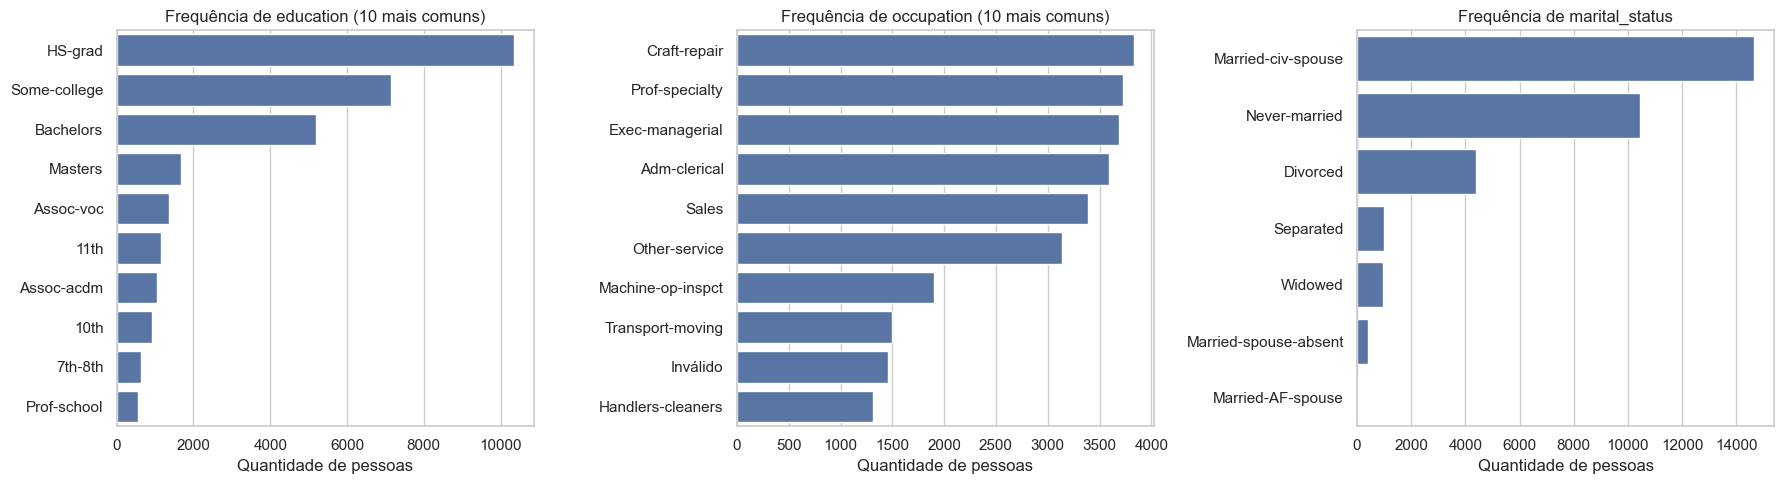

In [9]:
categorical_cols = ['workclass', 'education', 'marital_status', 'occupation',
                    'relationship', 'race', 'sex', 'native_country']

# Resumo de todas as categóricas: nº de categorias, categoria mais comum e seu % na base.
resumo = data[categorical_cols].describe().T[['unique', 'top', 'freq']]
resumo['freq_%'] = (resumo['freq'] / len(data) * 100).astype(float).round(1)
display(resumo)

# Frequências (%) das três categóricas escolhidas; os ausentes aparecem como 'Ausente'.
selected_cat = ['education', 'occupation', 'marital_status']
for col in selected_cat:
    display((data[col].fillna('Ausente').value_counts(normalize=True) * 100).round(1).head(10).to_frame('%'))

# Gráficos de barras com as 10 categorias mais comuns de cada uma.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, selected_cat):
    sns.countplot(data=data, y=col, order=data[col].value_counts().head(10).index, ax=ax)
    ax.set_title(f'Frequência de {col}' + (' (10 mais comuns)' if data[col].nunique() > 10 else ''))
    ax.set_xlabel('Quantidade de pessoas')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Interpretação**

- `education`: *HS-grad*, *Some-college* e *Bachelors* somam cerca de 70% da base.
- `occupation`: as cinco ocupações mais comuns têm entre 10% e 12% cada, sem categoria dominante. A categoria `Inválido` da seção 1.3 tem cerca de 4,6%, e os ausentes somam cerca de 5,6%.
- `marital_status`: *Married-civ-spouse* e *Never-married* cobrem quase 80% dos registros.
- Na tabela resumo, `native_country` tem 91% em *United-States*, `race` tem 86% em *White* e `sex` tem 67% de homens. Grupos pequenos têm poucas amostras, o que limita o que o modelo consegue aprender sobre eles.

## 3. Análise bivariada e multivariada

### 3.1 Correlação entre variáveis numéricas

A matriz inclui a renda convertida em 0 e 1 (`renda_50k`) para medir também a relação de cada numérica com o alvo. Como são só três numéricas, existem exatamente três pares possíveis, e os três scatter plots mostram todos eles.

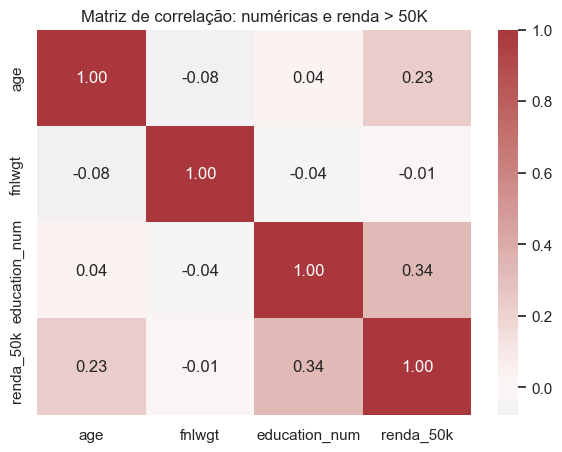

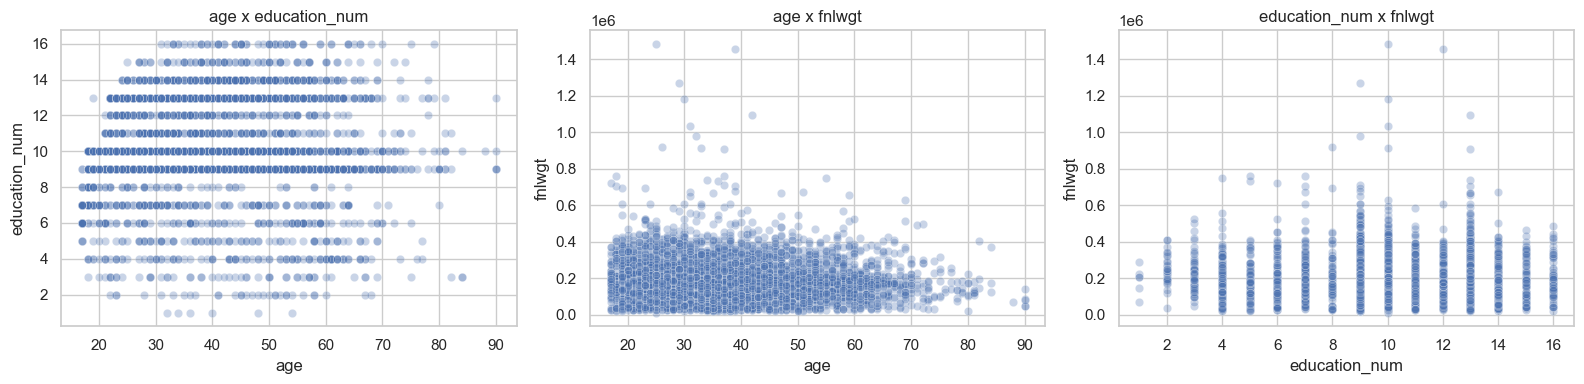

In [10]:
# Matriz de correlação das numéricas, com a renda convertida em 0/1 para comparar com o alvo.
corr = data[numeric_cols].assign(renda_50k=(data['income'] == '>50K').astype(int)).corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Matriz de correlação: numéricas e renda > 50K')
plt.show()

# Scatter plots dos três pares, com amostra de 5.000 pontos para o gráfico ficar legível.
amostra = data.sample(5000, random_state=RANDOM_STATE)
pares = [('age', 'education_num'), ('age', 'fnlwgt'), ('education_num', 'fnlwgt')]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (x, y_col) in zip(axes, pares):
    sns.scatterplot(data=amostra, x=x, y=y_col, alpha=0.3, ax=ax)
    ax.set_title(f'{x} x {y_col}')
plt.tight_layout()
plt.show()

**Interpretação**

- Entre as numéricas, todas as correlações são praticamente nulas, abaixo de 0,08 em módulo. Não há redundância: cada uma traz informação própria.
- Com o alvo, `education_num` tem a maior correlação (0,34), seguida de `age` (0,23). `fnlwgt` tem -0,01, ou seja, nenhuma relação com a renda, o que confirma que é só um peso amostral.
- Os scatter plots não mostram tendência em nenhum par. As faixas de pontos alinhados vêm de `education_num` ser discreta.

### 3.2 Variáveis categóricas × renda

Foram escolhidas `education`, para verificar se a renda acompanha a ordem dos níveis, o que sustenta usar `education_num` no lugar dela; `marital_status`, uma das categóricas com maior diferença de renda entre categorias; e `sex`, para medir o viés demográfico que o enunciado pede para investigar.

income,<=50K,>50K
education,,
Doctorate,25.6,74.4
Prof-school,25.9,74.1
Masters,44.0,56.0
Bachelors,58.4,41.6
Assoc-voc,73.9,26.1
Assoc-acdm,75.1,24.9
Some-college,80.9,19.1
HS-grad,84.0,16.0
12th,92.5,7.5


income,<=50K,>50K
marital_status,,
Married-civ-spouse,55.3,44.7
Married-AF-spouse,56.5,43.5
Divorced,89.6,10.4
Widowed,91.4,8.6
Married-spouse-absent,92.0,8.0
Separated,93.4,6.6
Never-married,95.4,4.6


income,<=50K,>50K
sex,,
Male,69.4,30.6
Female,89.0,11.0


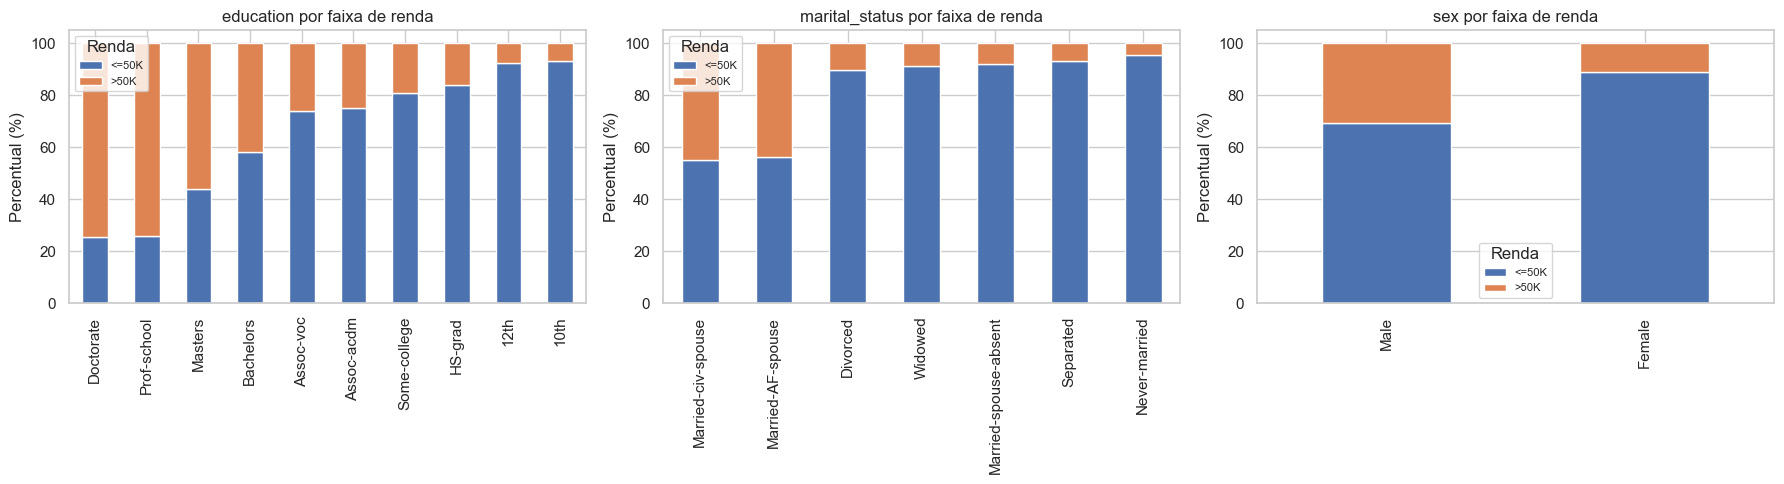

In [11]:
# Para cada variável: tabela de contingência com o % de cada faixa de renda por categoria
# e gráfico de barras empilhadas, ordenados da maior para a menor taxa de >50K.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['education', 'marital_status', 'sex']):
    tabela = pd.crosstab(data[col], data['income'], normalize='index').mul(100).round(1)
    tabela = tabela.sort_values('>50K', ascending=False)
    display(tabela)
    tabela.head(10).plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{col} por faixa de renda')
    ax.set_xlabel('')
    ax.set_ylabel('Percentual (%)')
    ax.legend(title='Renda', fontsize=8)
plt.tight_layout()
plt.show()

**Interpretação**

- `education`: a renda acompanha a ordem dos níveis. A taxa de `>50K` vai de 16% em *HS-grad* para 74% em *Doctorate* e *Prof-school*, e fica abaixo de 8% em todos os níveis sem ensino médio completo. A ordem de `education_num` representa bem a variável.
- `marital_status`: 45% dos casados (*Married-civ-spouse*) ganham `>50K`, contra 10% dos divorciados e 5% dos solteiros.
- `sex` revela um **viés** dos dados: 31% dos homens ganham `>50K`, contra 11% das mulheres, quase o triplo. Um modelo treinado nesta base vai reproduzir essa diferença, então a avaliação na próxima etapa deve comparar as métricas entre homens e mulheres.

### 3.3 Variáveis numéricas × categóricas

Cada boxplot testa uma hipótese levantada nas seções anteriores:

- `age` por `marital_status`: verificar se a diferença de renda entre estados civis se mistura com a idade.
- `education_num` por `sex` e renda: verificar se a diferença de renda entre homens e mulheres se explica por escolaridade.
- `education_num` por `occupation`: verificar se ocupação e escolaridade são redundantes, já que as duas vão para o modelo.

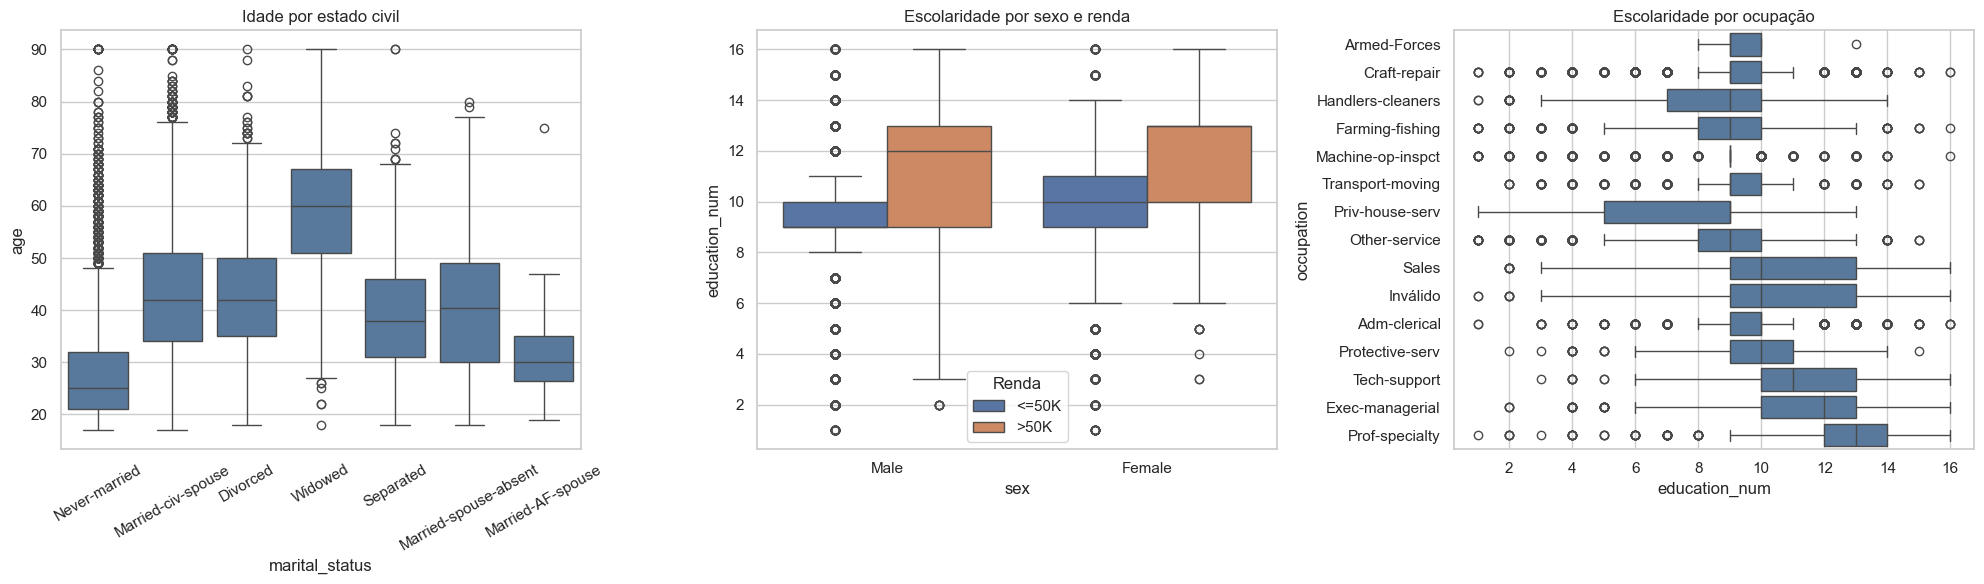

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1) Idade por estado civil.
sns.boxplot(data=data, x='marital_status', y='age', ax=axes[0], color='#4c78a8')
axes[0].set_title('Idade por estado civil')
axes[0].tick_params(axis='x', rotation=30)

# 2) Escolaridade por sexo, separando as duas faixas de renda.
sns.boxplot(data=data, x='sex', y='education_num', hue='income', ax=axes[1])
axes[1].set_title('Escolaridade por sexo e renda')
axes[1].legend(title='Renda')

# 3) Escolaridade por ocupação, ordenada pela mediana para facilitar a leitura.
ordem = data.groupby('occupation')['education_num'].median().sort_values().index
sns.boxplot(data=data, y='occupation', x='education_num', order=ordem, ax=axes[2], color='#4c78a8')
axes[2].set_title('Escolaridade por ocupação')

plt.tight_layout()
plt.show()

**Interpretação**

- **Idade por estado civil:** solteiros têm mediana de 25 anos, casados 42 e viúvos 60. Parte da diferença de renda entre estados civis vem da idade, porque os solteiros são, em geral, jovens no início da carreira.
- **Escolaridade por sexo e renda:** nas duas faixas de renda, as mulheres têm escolaridade mediana um nível acima da dos homens: 10 contra 9 em `<=50K` e 13 contra 12 em `>50K`. Mulheres mais escolarizadas estão na mesma faixa de renda que homens menos escolarizados, o que reforça o viés visto na seção 3.2.
- **Escolaridade por ocupação:** *Prof-specialty* tem mediana 13 e *Exec-managerial* 12, enquanto as ocupações manuais ficam em 9. Mas há muita sobreposição, e *Sales* vai de 9 a 13 entre os quartis. As duas variáveis são relacionadas sem ser redundantes, então ambas ficam no modelo. A categoria `Inválido` ocupa a mesma faixa de *Sales*, de 9 a 13, bem espalhada, o que é coerente com um grupo que mistura ocupações diferentes.

### 3.4 Síntese dos achados

1. **Assimetria:** só `fnlwgt` é bem assimétrica, e ela será descartada. `age` tem assimetria leve e `education_num` é discreta.
2. **Associados a maior renda:** mais escolaridade, ser casado e mais idade. `sex` também, o que é viés: nas duas faixas de renda, as mulheres têm escolaridade mediana maior que a dos homens.
3. **Outliers:** são valores reais, como idosos e níveis baixos de escolaridade, e não erros. Serão mantidos.
4. **Redundâncias:** `education` é idêntica a `education_num`, e `fnlwgt` não tem relação com a renda. Ambas serão removidas.
5. **Qualidade:** os ausentes de `workclass` e `occupation` marcam pessoas sem vínculo de trabalho. O valor inválido em `occupation` é um grupo de renda alta, mantido como categoria própria.

## 4. Pré-processamento para modelagem

### 4.1 Estratégias escolhidas e justificativas

| Etapa | Decisão | Justificativa (achado da EDA) |
|---|---|---|
| **Remoção de features** | Descartar `education` e `fnlwgt` | `education` tem correspondência exata com `education_num` (seção 1.3), que já guarda a ordem dos níveis. `fnlwgt` é peso amostral e tem correlação de -0,01 com a renda (seção 3.1). |
| **Valor inválido em `occupation`** | Manter como a categoria `Inválido`, criada na seção 1.3 | As 1.462 linhas não são ruído: cerca de 53% delas ganham `>50K`, contra cerca de 10% das linhas com `?`. Tratá-las como ausentes misturaria os dois grupos. Por ser um erro deste arquivo, o efeito dessa categoria não deve ser generalizado para dados novos. |
| **Valores ausentes** | Imputar a categoria `Desconhecido` em `workclass`, `occupation` e `native_country` | Em `workclass` e `occupation`, a ausência marca pessoas sem vínculo de trabalho, com cerca de 10% de renda alta. Imputar a moda (`Private`) daria um emprego a quem não tem. Em `native_country` são só 25 linhas, e a mesma regra mantém o pipeline simples. As numéricas não têm ausentes. |
| **Outliers** | Manter todos os registros, sem transformação | Os pontos fora dos boxplots são valores reais: 139 pessoas acima de 78 anos e 1.155 nos níveis mais baixos de escolaridade. Removê-los descartaria grupos reais e enviesaria o modelo. A única variável muito assimétrica, `fnlwgt`, já é descartada. |
| **Encoding** | One-Hot Encoding com `handle_unknown='ignore'` | As categóricas são nominais, sem ordem, e *label encoding* criaria uma ordem falsa. A cardinalidade é baixa: o resultado tem 89 colunas, um tamanho administrável. Categorias novas no teste viram zeros em vez de erro. |
| **Escala** | `StandardScaler` (z-score) | Deixa `age` e `education_num` com média 0 e desvio 1, para que nenhuma variável domine pela unidade em Regressão Logística, KNN, SVM e PCA. O Min-Max usa só o mínimo e o máximo, então os poucos casos de 90 anos definiriam a escala de todos. |

### 4.2 Pipeline de pré-processamento

O pipeline aplica as decisões da tabela acima. O `ColumnTransformer` trata cada grupo de colunas de um jeito e descarta as colunas não listadas, `education` e `fnlwgt`.

In [13]:
# Colunas que entram no modelo. education e fnlwgt não são listadas e são descartadas.
numeric_features = ['age', 'education_num']
categorical_features = ['workclass', 'marital_status', 'occupation', 'relationship',
                        'race', 'sex', 'native_country']

# Categóricas: ausentes viram 'Desconhecido' e cada categoria vira uma coluna 0/1.
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Numéricas não têm ausentes, então só recebem padronização.
preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

# fit só no treino; o teste recebe apenas transform, sem vazamento de dados.
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print('Treino processado:', X_train_prep.shape, '| Teste processado:', X_test_prep.shape)

Treino processado: (25505, 89) | Teste processado: (6377, 89)


### 4.3 PCA nas variáveis numéricas

O PCA usa as três numéricas do dataset, `age`, `fnlwgt` e `education_num`, padronizadas com ajuste só no treino. `fnlwgt` entra aqui mesmo sendo descartada do pipeline: o objetivo é visualizar a estrutura de todas as numéricas e verificar se `fnlwgt` ajuda a separar as classes.

,variancia_%,acumulada_%
PC1,37.1,37.1
PC2,32.2,69.3
PC3,30.7,100.0


,PC1,PC2,PC3
age,-0.610,-0.416,0.675
fnlwgt,0.630,0.263,0.731
education_num,-0.481,0.871,0.102


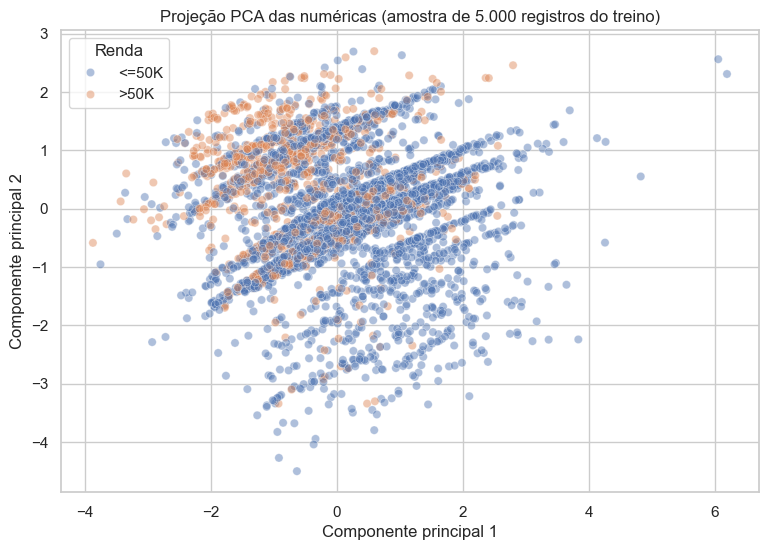

In [14]:
# Padroniza as três numéricas (ajuste só no treino) e aplica o PCA.
X_num = StandardScaler().fit_transform(X_train[numeric_cols])
pca = PCA(random_state=RANDOM_STATE).fit(X_num)

# Variância explicada por componente e acumulada.
variancia = pd.DataFrame({
    'variancia_%': (pca.explained_variance_ratio_ * 100).round(1),
    'acumulada_%': (pca.explained_variance_ratio_.cumsum() * 100).round(1)
}, index=['PC1', 'PC2', 'PC3'])
display(variancia)

# Loadings: peso de cada variável original em cada componente.
display(pd.DataFrame(pca.components_.T, index=numeric_cols, columns=['PC1', 'PC2', 'PC3']).round(3))

# Projeção nas duas primeiras componentes, colorida pela renda.
componentes = pd.DataFrame(pca.transform(X_num)[:, :2], columns=['PC1', 'PC2'])
componentes['income'] = y_train.values
plt.figure(figsize=(9, 6))
sns.scatterplot(data=componentes.sample(5000, random_state=RANDOM_STATE),
                x='PC1', y='PC2', hue='income', alpha=0.45)
plt.title('Projeção PCA das numéricas (amostra de 5.000 registros do treino)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Renda')
plt.show()

**Interpretação do PCA**

- **Variância explicada:** as três componentes explicam 37%, 32% e 31%, quase o mesmo tanto cada. Isso acontece porque as numéricas são praticamente não correlacionadas (seção 3.1): não há redundância para o PCA comprimir, e ficar com duas componentes perderia quase um terço da informação. Para a modelagem, é melhor usar as variáveis originais.
- **Loadings:** PC1 opõe `fnlwgt`, com peso positivo, a `age` e `education_num`, com pesos negativos. PC2 é dominada por `education_num`.
- **Separabilidade:** a classe `>50K` se concentra na região de PC1 negativo e PC2 positivo, que corresponde a pessoas mais velhas e mais escolarizadas. Há muita sobreposição com `<=50K`, então as numéricas sozinhas separam só parcialmente as classes, e as categóricas serão essenciais. As faixas diagonais do gráfico vêm dos níveis discretos de `education_num`.
- **Importância das features:** o sinal de renda está em `education_num` e `age`. `fnlwgt` tem peso grande em PC1, mas correlação nula com a renda: adiciona variância sem informação, o que confirma a decisão de removê-la.

### 4.4 Pipeline final para a etapa de classificação

Basta acoplar um classificador ao `preprocessor`. O exemplo abaixo ainda não é treinado nem avaliado. Isso fica para a próxima etapa, em que se recomenda comparar Regressão Logística, Árvore de Decisão e Random Forest com validação cruzada estratificada e as métricas precisão, recall, F1-score e ROC-AUC.

In [15]:
from sklearn.linear_model import LogisticRegression

# Pipeline completo: pré-processamento seguido do classificador.
# class_weight='balanced' compensa o desbalanceamento 3:1 visto na seção 1.5.
modelo = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
modelo

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

## 5. Relatório: principais achados e estratégia proposta

**Dados**

- 31.947 registros na versão do Kaggle, 31.882 após remover duplicatas, com 11 features (3 numéricas e 8 categóricas) e alvo binário desbalanceado na proporção 3:1.
- Ausentes só em `workclass`, `occupation` e `native_country`. Em `workclass` e `occupation`, marcam pessoas sem vínculo de trabalho.
- Inconsistência: 1.462 linhas com o texto "occupation" como ocupação. É um grupo com cerca de 53% de renda alta, mantido como categoria própria.

**Relações com o alvo**

- Numéricas mais relacionadas à renda: `education_num` (0,34) e `age` (0,23). `fnlwgt` não tem relação, e `education` repete `education_num`.
- Escolaridade e estado civil separam bem as classes, e parte do efeito do estado civil vem da idade.
- As numéricas são praticamente não correlacionadas. O PCA não comprime a informação e separa as classes só parcialmente.
- Viés: homens têm quase o triplo da taxa de `>50K` das mulheres, e nas duas faixas de renda as mulheres têm escolaridade mediana maior que a dos homens.

**Estratégia para a modelagem**

- Pipeline com remoção de `education` e `fnlwgt`, z-score em `age` e `education_num`, e categoria `Desconhecido` com one-hot nas categóricas.
- Split estratificado 80/20 e validação cruzada estratificada.
- Métricas focadas na classe minoritária (precisão, recall, F1-score e ROC-AUC), `class_weight='balanced'` e comparação das métricas entre homens e mulheres.

## Referências

- Dataset [Adult Income Census](https://www.kaggle.com/datasets/anaghakp/adult-income-census), Kaggle. Origem: Becker, B. e Kohavi, R. (1996). *Adult* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20
- Documentação do [Pandas](https://pandas.pydata.org/docs/), [Scikit-learn](https://scikit-learn.org/stable/), [Seaborn](https://seaborn.pydata.org/) e [Matplotlib](https://matplotlib.org/stable/).